In [88]:
import numpy as np 
import scipy
from math import floor

import jax
import jax.numpy as jnp 
import matplotlib.pyplot as plt


from kltpicker_3d.alt_least_squares import alternating_least_squares_solver
from kltpicker_3d.tests.exp_spectrum import *
from kltpicker_3d.tests.gaussian_spectrum import * 
from kltpicker_3d.utils import * 


jax.config.update("jax_default_device", jax.devices("cpu")[0])

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.5
})

### Clean sphere-like 3D signal

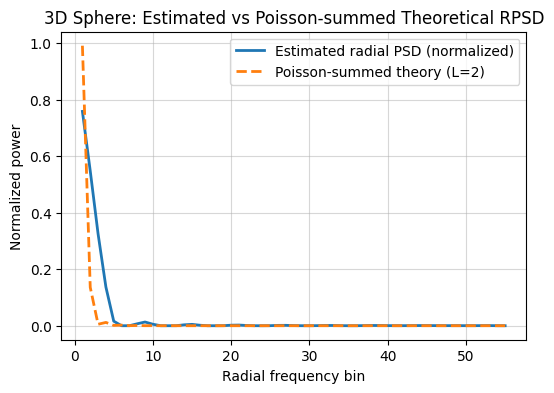

In [55]:
# Clean sphere patch
R = 16
a = 2*R + 1
#M = floor(0.8*a)
#if M % 2 == 0:
#    M -= 1
M = 2*R + 1
x,y,z = np.mgrid[:M,:M,:M]
c = (M-1)/2.0
patch = (((x-c)**2 + (y-c)**2 + (z-c)**2) <= R*R).astype(np.float32)

x = np.fft.fftfreq(M)
KX, KY, KZ = np.meshgrid(x, x, x, indexing="ij")
KR = np.sqrt(KX**2 + KY**2 + KZ**2)

sigma =0.1
H = np.exp(-(KR / sigma)**2)
F = np.fft.fftn(patch)
patch = np.fft.ifftn(F*H).real
patch = patch - patch.mean()
patch_power = (patch**2).mean()

# Estimated 3D PSD
psd = np.array(
    estimate_isotropic_powerspectrum_tensor(
        jnp.asarray(patch), 
        max_d=int(np.floor(M/3))
        )
)
S = psd.shape[0]
mid = S//2

# Radial average of estimated PSD
ix,iy,iz = np.mgrid[:S,:S,:S]
r = np.sqrt((ix-mid)**2 + (iy-mid)**2 + (iz-mid)**2)
rbin = np.rint(r).astype(int)
maxbin = rbin.max()
num = np.bincount(rbin.ravel(), weights=psd.ravel(), minlength=maxbin+1)
den = np.bincount(rbin.ravel(), minlength=maxbin+1)
rad_est = np.divide(num, den, out=np.zeros_like(num), where=den>0)


def F_sphere_cont(k, R):
    out = np.empty_like(k, dtype=np.float64)
    kz = k > 1e-12
    out[kz] = 4.0 * np.pi * (np.sin(k[kz] * R) - (k[kz] * R) * np.cos(k[kz] * R)) / (k[kz]**3)
    out[~kz] = (4.0 / 3.0) * np.pi * R**3 # Limit at 0
    return out

# centered angular-frequency grid matching shifted PSD indexing
w = (np.arange(S) - mid) * (2.0 * np.pi / S)
WX, WY, WZ = np.meshgrid(w, w, w, indexing="ij")

# truncate Poisson sum to |m_i| <= L
L = 2 # increase to 3 for higher accuracy, slower compute
A = np.zeros((S, S, S), dtype=np.float64)

for mx in range(-L, L + 1):
    for my in range(-L, L + 1):
        for mz in range(-L, L + 1):
            K = np.sqrt((WX + 2*np.pi*mx)**2 +
                        (WY + 2*np.pi*my)**2 +
                        (WZ + 2*np.pi*mz)**2)
            A += F_sphere_cont(K, R)


psd_th_3d = np.abs(A)**2  # aliased theoretical power

# radial average of theoretical 3D PSD on same bins
num_th = np.bincount(rbin.ravel(), weights=psd_th_3d.ravel(), minlength=maxbin + 1)
rad_th = np.divide(num_th, den, out=np.zeros_like(num_th), where=den > 0)

# Normalize for scale comparison; exclude DC
rb = np.arange(maxbin + 1)
use = rb >= 1
rad_est_n = rad_est / (np.linalg.norm(rad_est[use]) + 1e-12)
rad_th_n = rad_th / (np.linalg.norm(rad_th[use]) + 1e-12)


plt.figure(figsize=(6, 4))
plt.plot(rb[use], rad_est_n[use], label="Estimated radial PSD (normalized)", lw=2)
plt.plot(rb[use], rad_th_n[use], "--", label=f"Poisson-summed theory (L={L})", lw=2)
plt.xlabel("Radial frequency bin")
plt.ylabel("Normalized power")
plt.title("3D Sphere: Estimated vs Poisson-summed Theoretical RPSD")
plt.legend()
plt.show()

### Detection of constant-spheres in noisy tomogram

In [144]:
N = 300
K = 200
R = 16 # True radius 
a = 2*R + 1 # Diameter of particle 
M = 2*R+1
if M % 2 == 0:
    M-=1
S = 2*M-1
tomogram = np.zeros((N,N,K),dtype=np.uint8)

rng = np.random.default_rng(0) 
flat = rng.choice(tomogram.size, size=10,replace=False)
centers = np.column_stack(np.unravel_index(flat, tomogram.shape))

dx, dy, dz = np.mgrid[-R:R+1, -R:R+1, -R:R+1]
sphere = (dx**2 + dy**2 + dz**2) <= R**2 
offsets = np.column_stack((dx[sphere], dy[sphere], dz[sphere]))

for cx, cy, cz in centers:
    pts = offsets + np.array([cx, cy, cz])         
    valid = (
        (0 <= pts[:, 0]) & (pts[:, 0] < N) &
        (0 <= pts[:, 1]) & (pts[:, 1] < N) &
        (0 <= pts[:, 2]) & (pts[:, 2] < K)
    )
    pts = pts[valid]
    tomogram[pts[:, 0], pts[:, 1], pts[:, 2]] = 1

# Bandlimiting the tomogram
# Convoluting is a distributive, so as our tomogram is a sum of sphere indicators it applies to each sphere.  
Nk = np.fft.fftfreq(N)
Kk = np.fft.fftfreq(K)

KX,KY,KZ = np.meshgrid(Nk,Nk,Kk) 
KR = np.sqrt(KX**2 + KY**2 + KZ**2)

sigma =0.1
H = np.exp(-(KR / sigma)**2)
c = np.sqrt(-np.log(1e-16)*2*sigma**2)

# Convolution is distributive 
F = np.fft.fftn(tomogram)
tomogram = np.fft.ifftn(F*H).real
tomogram_clean = tomogram.copy() 
scale = 2 
tomogram = tomogram + np.random.normal(scale=scale, size=tomogram.shape)

# w = np.lib.stride_tricks.sliding_window_view(tomogram, (M,M,M))
# patches = w[::16,::16,::16].reshape(-1,M,M,M)

In [145]:
s = tomogram_clean - tomogram_clean.mean()
P_s = np.mean(s**2)
P_n = scale**2
snr_lin = P_s / P_n
snr_lin

np.float64(0.0016574748112401568)

In [146]:
micro_size = np.min(tomogram.shape)
m = int(np.floor(micro_size/ M))

patches = np.zeros((m**3,M,M,M))
for k in range(m**3):
    i = k // (m * m)          
    j = (k // m) % m         
    l = k % m               
    patches[k] = tomogram[i * M:(i + 1) * M,j * M:(j + 1) * M,l * M:(l + 1) * M]

In [147]:
vect_spectrum_estimation = jax.vmap(estimate_isotropic_powerspectrum_tensor,
                                    in_axes=(0,None))
max_d = int(np.floor(M/2))

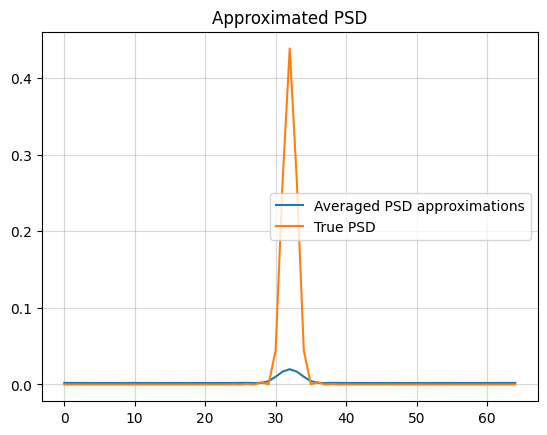

In [148]:
samples = patches - jnp.mean(patches, axis=(1,2,3)).reshape(-1,1,1,1)
psd = vect_spectrum_estimation(samples,max_d)  

avg_psd = np.mean(psd,axis=0)
avg_psd /= np.linalg.norm(avg_psd)
mid = avg_psd.shape[0]//2

H = psd_th_3d / np.linalg.norm(psd_th_3d)
plt.plot(avg_psd[mid,mid,:], label='Averaged PSD approximations')
plt.plot(H[mid,mid,:], label="True PSD")
plt.legend()
plt.title("Approximated PSD");

In [149]:
def trigonometric_interpolation(x,y,z):
    n = x.shape[0]
    
    scale = (x[1] - x[0]) * n / 2 
    x_scaled = (x / scale) * jnp.pi / 2 
    z_scaled = (z / scale) * jnp.pi / 2

    delta = z_scaled[:, None] - x_scaled[None, :]
    # We take n to be only even 
    M = jnp.sin(n*delta) / (n *jnp.sin(delta))
    #if n % 2 == 0:
    #    M = np.sin(n*delta) / (n *jnp.sin(delta))
    #else:
    #    M = np.sin(n*delta)/ (n*jnp.tan(delta))
    M = M.at[jnp.isclose(delta,0)].set(1.0)

    p = M @ y 
    return p

def radial_average(X, bins, n):
    S = np.zeros(n)
    for j in range(n):
        bin_len = bins[j][0].size
        if bin_len != 0:    
            S[j] += np.mean(X[bins[j]])
    return S


def radial_average_batch(Xb, rbin, nbins=None):
    if nbins is None:
        nbins = int(rbin.max()) + 1
    B = Xb.shape[0]
    out = np.empty((B, nbins), dtype=np.float64)
    den = np.bincount(rbin.ravel(), minlength=nbins).astype(np.float64)
    for b in range(B):  # light loop over batch only
        num = np.bincount(rbin.ravel(), weights=Xb[b].ravel(), minlength=nbins)
        out[b] = np.divide(num, den, out=np.zeros_like(num, dtype=np.float64), where=den > 0)
    return out

In [150]:
uniform_points, bins = generate_uniform_radial_sampling_points(S,c)
rblocks = np.array(
    [radial_average(psd[k], bins, len(bins)) for k in range(patches.shape[0])]
)
factorization = alternating_least_squares_solver(rblocks,500,1e-4)

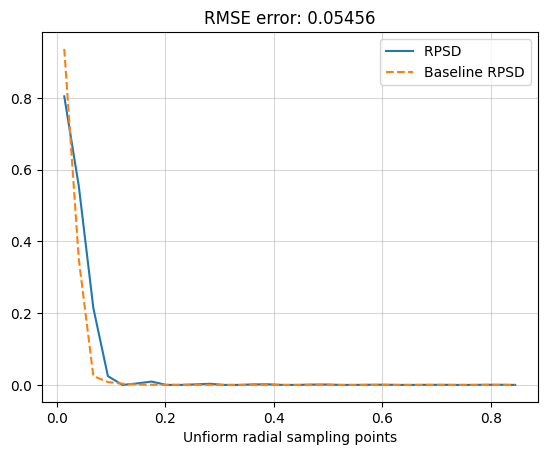

In [120]:
particle_psd = factorization.gamma
noise_psd = factorization.v

noise_psd /= np.linalg.norm(noise_psd)
particle_psd /= np.linalg.norm(particle_psd)

extracted_alphas = factorization.alpha

true_rpsd = radial_average(psd_th_3d,bins, len(bins))
true_rpsd /= np.linalg.norm(true_rpsd)

mse = np.sqrt(((particle_psd - true_rpsd)**2).mean())

plt.plot(uniform_points,particle_psd, label='RPSD ')
plt.plot(uniform_points,true_rpsd, "--",label='Baseline RPSD')
plt.xlabel('Unfiorm radial sampling points')
plt.title(f"RMSE error: {mse:.4}")
plt.legend();

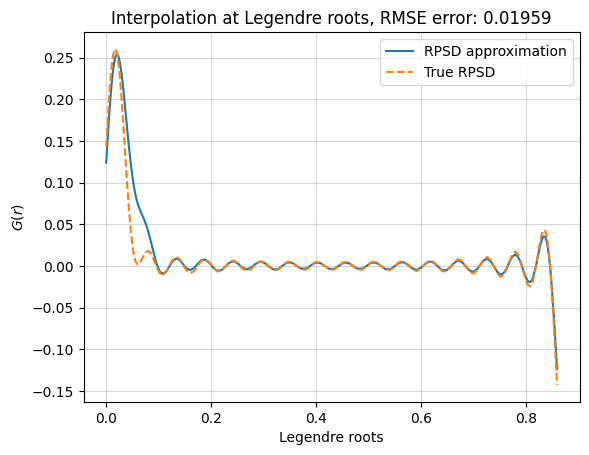

In [151]:
particle_psd = factorization.gamma
X,w = scipy.special.roots_legendre(150)
X_scaled = c/2*X + c/2
Gx = trigonometric_interpolation(uniform_points, particle_psd, X_scaled)
Gx /= np.linalg.norm(Gx)
Gx_true = trigonometric_interpolation(uniform_points, true_rpsd, X_scaled)
Gx_true /= np.linalg.norm(Gx_true)
plt.title("RPSD interpolation")
plt.plot(X_scaled, Gx, label='RPSD approximation')
plt.plot(X_scaled, Gx_true,'--', label='True RPSD')
plt.title(f"Interpolation at Legendre roots, RMSE error: {np.sqrt(np.mean((Gx_true - Gx)**2)):.5f}")
plt.xlabel("Legendre roots")
plt.ylabel(r'$G(r)$')
plt.legend();

In [152]:
from kltpicker_3d.fredholm_solver import solve_radial_fredholm_equation

max_order = 100 
eigvals, eigfuncs = [],[]
for i in range(max_order):
    lambdas, funcs,W = solve_radial_fredholm_equation(Gx,i,a,c)
    eigvals.append(lambdas)
    eigfuncs.append(funcs)

eigfuncs = np.array(eigfuncs).reshape(-1,150)
eigvals = np.array(eigvals).reshape(-1)

orders = np.tile(np.arange(max_order).reshape(-1, 1), (1, 150)).reshape(-1)

idx = np.argsort(eigvals)[::-1]
orders = orders[idx]

eigfuncs = eigfuncs[idx,:]
eigvals = eigvals[idx]

idx = np.where(eigvals > np.spacing(1))[0]
eigvals = eigvals[idx]
eigfuncs = eigfuncs[idx,:]
orders = orders[idx]

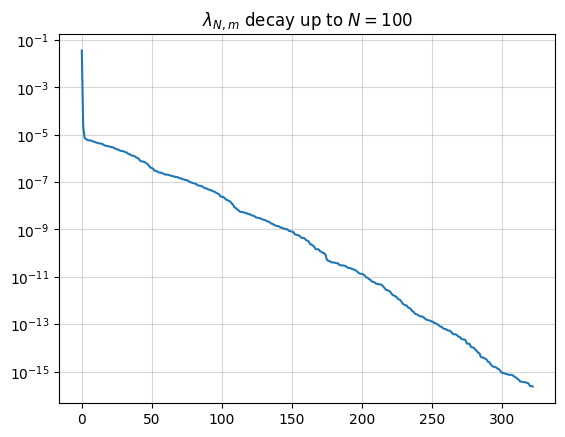

In [153]:
plt.title(r"$\lambda_{N,m}$ decay up to $N=100$")
plt.plot(eigvals)
plt.yscale('log')

In [154]:
from scipy.special import spherical_jn

a = 2*R+1
template_size = floor(a)
radmax = np.floor((template_size - 1)/2)
grid = np.arange(-radmax,radmax+1,1)
X,Y,Z = np.meshgrid(grid,grid,grid)
r_tensor = np.sqrt(X**2 + Y**2 + Z**2)
rho_uniform, idx = np.unique(r_tensor,return_inverse=True)

rho_leg, w = scipy.special.roots_legendre(150)
rho_leg_a =  (a / 2.0) * rho_leg + a / 2.0  
rho_leg_c =  c / 2 * rho_leg + c / 2

# Truncates the spectra to contain 99% of the data
eigval_cumsum = np.cumsum(eigvals / np.sum(eigvals))
truncate_idx = (eigval_cumsum > 0.99).argmax() + 1

eigfuncs = eigfuncs[:truncate_idx,...]
eigvals = eigvals[:truncate_idx]
orders = orders[:truncate_idx,...]

r_grid_uni = np.outer(rho_uniform, rho_leg_c)
r_grid_leg = np.outer(rho_leg_a, rho_leg_c)

def Hn_scipy(x,N):
    return 4*np.pi * ((1j**N) * spherical_jn(N,x))

# Hn evaluated at multiples of uniform radial points
Hn_uniform = np.array(
    [Hn_scipy(r_grid_uni,N) for N in range(orders.max()+1)]
)

# Hn evaluated at multiples Legendre roots 
Hn_leg = np.array(
    [Hn_scipy(r_grid_leg,N) for N in range(orders.max()+1)]
)

Hn_leg = Hn_leg[orders]
Hn_uniform = Hn_uniform[orders]

sgn = np.where(orders % 2 == 1, -1, 1)
D = (c/2) * w * Gx * (rho_leg_c**2)
W = a * 0.5 * w* rho_leg_a**2

#H_right = np.swapaxes(sgn[:,None,None]* Hn_leg, -1,-2)
H_right = sgn[:,None,None]* Hn_leg
psi = (Hn_uniform * D[None,None,:]) @ H_right
eigfuncs_uniform = np.einsum('bik,k,bk->bi', psi,W,eigfuncs) / eigvals[:,None]
radial_templates = eigfuncs_uniform[:,idx]

In [155]:
theta = np.arctan2(Y, X)
phi = np.arctan2(Z,np.sqrt(X**2 + Y**2))

N_max = orders.max()+1
sph_harm = np.zeros((N_max+1,N_max+1) + theta.shape, dtype=np.complex64)
for N in range(N_max+1):
    for m in range(N+1):
        sph_harm[N,m] = scipy.special.sph_harm(m,N,theta,phi)

templates = sph_harm[orders]*radial_templates[:,None,...]

In [156]:
n_radial, n_harm, nx, ny, nz = templates.shape
psi = templates.reshape(n_radial * n_harm, nx * ny * nz)
eigvals_r = np.repeat(eigvals,n_radial * n_harm)

patches_var = jnp.var(samples,axis=(1,2,3))
patches_var = patches_var.sort()
noise_var_approx = jnp.mean(
    patches_var[:jnp.floor(0.25 * patches_var.size).astype('int')]
)

Q,R = np.linalg.qr(psi.T)
H = R @ np.diag(eigvals_r) @ R.T + noise_var_approx * np.eye(R.shape[0])
H_inv = np.linalg.inv(H)
T = (1 / noise_var_approx) * np.eye(R.shape[0]) - H_inv 

I = np.array(samples).reshape(samples.shape[0],-1)
mu = np.linalg.slogdet((1/ noise_var_approx) * H)[1]


D,P = np.linalg.eigh(T)
D, P = D[::-1],P[:,::-1]

x_num = tomogram.shape[0] - M + 1 
z_num = tomogram.shape[2] - M + 1


B = Q @ P
kernels = B.T.reshape(n_radial * n_harm, M,M,M)
score_mat = np.zeros((x_num,x_num,z_num))

for i in range(kernels.shape[0]):
    kernel = np.conj(np.flip(kernels[i], axis=(0,1,2)))
    response = scipy.signal.fftconvolve(tomogram, kernel,mode='valid')
    score_mat += D[i] * np.abs(response)**2

score_mat = score_mat - mu 
# U = I @ Q
# scores = U @ T @ U.T
# scores = np.abs(scores.T) - mu 

/scratch/home/moshemaymon/.conda/envs/moshiko/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:118: UserWarning: Explicitly requested dtype int requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


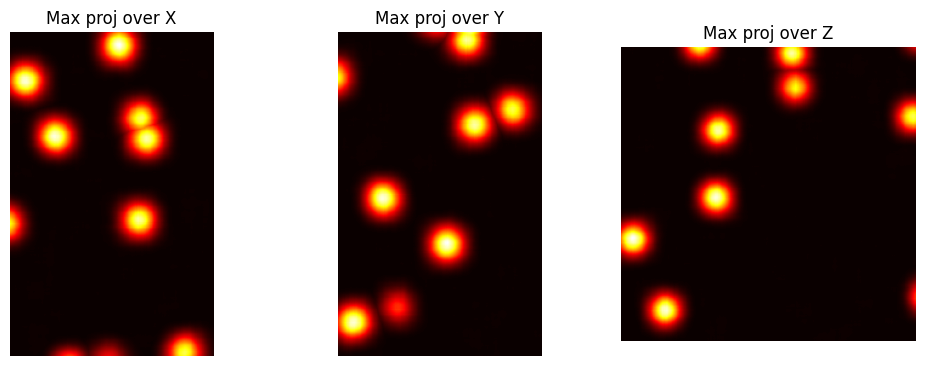

In [157]:
S = np.asarray(score_mat)

fig, ax = plt.subplots(1, 3, figsize=(10,4))
ax[0].imshow(S.max(axis=0), cmap="hot"); ax[0].set_title("Max proj over X")
ax[1].imshow(S.max(axis=1), cmap="hot"); ax[1].set_title("Max proj over Y")
ax[2].imshow(S.max(axis=2), cmap="hot"); ax[2].set_title("Max proj over Z")
plt.tight_layout()
for a in ax: a.axis("off")
plt.show()

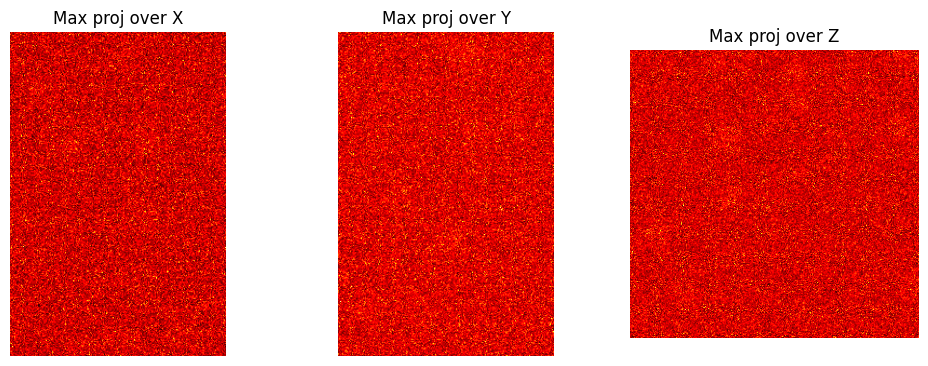

In [158]:
fig, ax = plt.subplots(1, 3, figsize=(10,4))
ax[0].imshow(tomogram.max(axis=0), cmap="hot"); ax[0].set_title("Max proj over X")
ax[1].imshow(tomogram.max(axis=1), cmap="hot"); ax[1].set_title("Max proj over Y")
ax[2].imshow(tomogram.max(axis=2), cmap="hot"); ax[2].set_title("Max proj over Z")
plt.tight_layout()
for a in ax: a.axis("off")
plt.show()

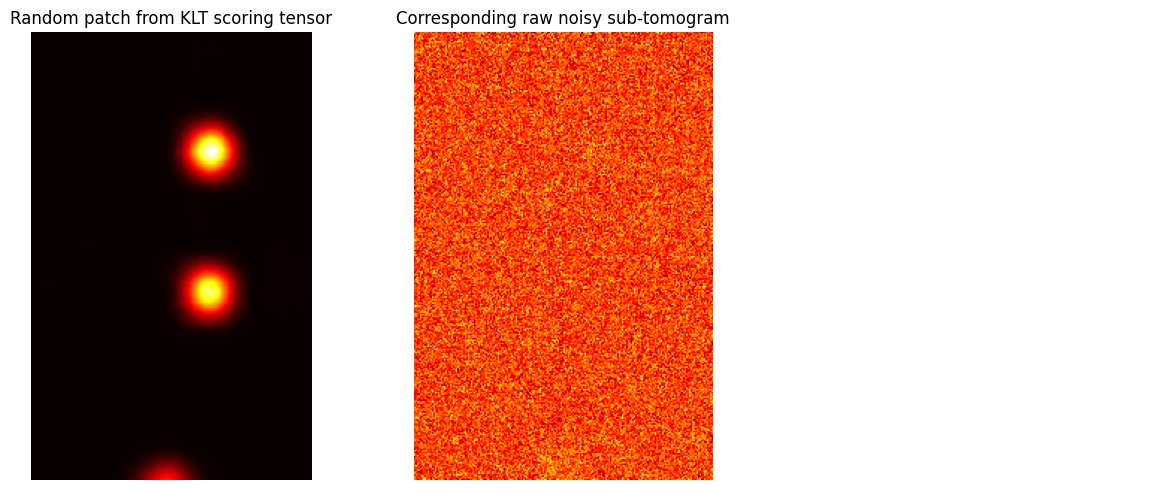

In [159]:
fig, ax = plt.subplots(1, 3, figsize=(12,5))

index = np.random.randint(0,S.shape[0])
ax[0].imshow(S[0],cmap='hot')
ax[0].set_title('Random patch from KLT scoring tensor')
ax[1].imshow(tomogram[0],cmap='hot')
ax[1].set_title('Corresponding raw noisy sub-tomogram')
for a in ax: a.axis("off")
plt.tight_layout()

In [160]:
import numpy as np

patch_size_pick_box = 16
patch_size_func = floor(0.4*M) 
num_of_particles = 10 
max_iter = 10**4
threshold = 0

def picking_from_scoring_vol_3d(score_vol):
    nx, ny, nz = score_vol.shape
    r_del = float(patch_size_pick_box)
    r2 = r_del ** 2
    center_offset = int(patch_size_func)

    # Grids for spherical suppression mask
    gx = np.arange(nx)[:, None, None]
    gy = np.arange(ny)[None, :, None]
    gz = np.arange(nz)[None, None, :]

    log_max = np.max(score_vol)
    eps = 1e-12

    scoring = score_vol.copy()
    particle_list = []

    num_limit = np.inf if num_of_particles == -1 else int(num_of_particles)
    num_picked = 0

    while num_picked < min(max_iter, num_limit):
        flat_idx = np.argmax(scoring)
        p_max = scoring.flat[flat_idx]

        if not (p_max > threshold):
            break

        ix, iy, iz = np.unravel_index(flat_idx, scoring.shape)

        # Convert valid-score index -> tomogram center coordinate
        cx = ix + center_offset
        cy = iy + center_offset
        cz = iz + center_offset

        particle_list.append([cx, cy, cz, p_max / (log_max + eps)])

        # 3D spherical NMS
        mask = (gx - ix) ** 2 + (gy - iy) ** 2 + (gz - iz) ** 2 <= r2
        scoring[mask] = -np.inf

        num_picked += 1

    particle_coords = np.array(particle_list, dtype=np.float64) if particle_list else np.zeros((0, 4))
    num_picked_particles = particle_coords.shape[0]


    return num_picked_particles, particle_coords


In [161]:
num_particles, coords = picking_from_scoring_vol_3d(score_mat)

In [162]:
coords

array([[187.        ,  23.        , 103.        ,   1.        ],
       [150.        ,  99.        ,  49.        ,   0.9642176 ],
       [253.        ,  54.        ,  25.        ,   0.95491213],
       [ 19.        , 167.        , 118.        ,   0.91001225],
       [ 89.        , 100.        , 125.        ,   0.90728871],
       [ 13.        ,  83.        , 121.        ,   0.84109803],
       [ 77.        , 278.        , 156.        ,   0.81630626],
       [ 51.        , 171.        ,  13.        ,   0.75738599],
       [242.        , 280.        ,  62.        ,   0.43308182],
       [ 13.        , 280.        ,  94.        ,   0.33214853]])

In [163]:
centers

array([[255,  56,  28],
       [243, 294,  64],
       [191,  26, 105],
       [153, 102,  53],
       [ 80, 280, 159],
       [ 12,  87, 123],
       [  4, 287,  97],
       [ 92, 104, 128],
       [ 52, 174,  11],
       [ 22, 171, 122]])

In [164]:
from scipy.spatial import cKDTree

pred = np.asarray(coords)[:, :3]
gt = np.asarray(centers)

tree = cKDTree(gt)
min_dists, nn_idx = tree.query(pred, k=1)   # nearest GT center for each predicted coord

# min_dists[i] = smallest distance from coords[i] to centers
# nn_idx[i]    = index in centers of that nearest center

print("Mean min dist:", min_dists.mean())
print("Median min dist:", np.median(min_dists))
print("Max min dist:", min_dists.max())

Mean min dist: 6.655522030273825
Median min dist: 5.608058350989902
Max min dist: 14.177446878757825


In [165]:
min_dists

array([ 5.38516481,  5.83095189,  4.12310563,  6.40312424,  5.83095189,
        4.58257569,  4.69041576,  3.74165739, 14.17744688, 11.78982612])

In [166]:
min_dists/16

array([0.3365728 , 0.36443449, 0.2576941 , 0.40019526, 0.36443449,
       0.28641098, 0.29315098, 0.23385359, 0.88609043, 0.73686413])

In [167]:
np.unique(nn_idx, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

In [168]:
len(np.unique(nn_idx))

10

The above means every true center is matched once exactly for each of the prediction, proving that indeed we have a one-to-one match with each generated sphere!